In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 필요 데이터 수집

In [ ]:
import tarfile

# tar = tarfile.open(r'/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_dataset.tar', 'r')
# tar.extractall()
# tar.close()

In [ ]:
# copyfile('/content/Dataset_User_Agreement.pdf','/content/drive/MyDrive/대학원/202309자료/추천시스템/Dataset_User_Agreement.pdf')

'/content/drive/MyDrive/대학원/202309자료/추천시스템/Dataset_User_Agreement.pdf'

In [ ]:
from shutil import copyfile

# copyfile(src, dst)

# copyfile('/content/yelp_academic_dataset_business.json','/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_academic_dataset_business.json')
# copyfile('/content/yelp_academic_dataset_review.json','/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_academic_dataset_review.json')
# copyfile('/content/yelp_academic_dataset_user.json','/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_academic_dataset_user.json')

'/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_academic_dataset_user.json'

In [ ]:
import tarfile

# tar = tarfile.open(r'/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_photos.tar', 'r')
# tar.extractall('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/photos/')
# tar.close()

In [ ]:
!pip install h3

In [ ]:
# 제이슨 파일 읽어오기
import pandas as pd
from datetime import datetime
# from pyspark.sql.types import *

!pip install git+https://github.com/coreylynch/pyFM
import numpy as np
import pandas as pd
from datetime import datetime
import json
from tqdm import tqdm
from sklearn.preprocessing import MultiLabelBinarizer
import itertools
import scipy as sp
from sklearn.feature_extraction import DictVectorizer
from pyfm import pylibfm
from sklearn.preprocessing import normalize
from scipy import sparse

from numpy.linalg import norm
from sklearn.pipeline import FeatureUnion
#from transformers import *
from scipy.sparse import coo_matrix
#import simplejson as json
from datetime import datetime
#from sklearn.model_selection import cross_validate
#from sklearn.cross_validation import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd
import h3

bs_data = pd.read_json(r'/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_academic_dataset_business.json'
, lines=True)

# 레스토랑업체만 필터링 (category에서 hotel검색시 이상한 업체들도 나와서 이름으로 필터링)
bs_data['name'] = bs_data['name'].str.lower()
bs_data = bs_data[bs_data['name'].str.contains('restaurant')]

# H3 추가
bs_data['h3'] = bs_data[['latitude', 'longitude']].apply(lambda x: h3.geo_to_h3(x['latitude'], x['longitude'], 7), axis=1)

# 랭크 추가
bs_data['rank'] = bs_data['stars'] * bs_data['review_count']

# ...그외 생략

 # CSV로 저장
bs_data.to_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/business.csv', index=False)

<ipython-input-13-0bb56358592b>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bs_data['h3'] = bs_data[['latitude', 'longitude']].apply(lambda x: h3.geo_to_h3(x['latitude'], x['longitude'], 7), axis=1)
<ipython-input-13-0bb56358592b>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bs_data['rank'] = bs_data['stars'] * bs_data['review_count']


In [ ]:
bs_data.shape

(3992, 16)

In [ ]:
data1 = pd.read_json(r'/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_academic_dataset_business.json'
, lines=True)
data1['categories'] = data1['categories'].str.lower()
mask_restaurants = data1['categories'].str.contains('restaurants')
mask_food = data1['categories'].str.contains('food')
restaurants_and_food = data1[mask_restaurants & mask_food]
restaurants_and_food_business_ids = restaurants_and_food.business_id.to_list()
data1['isRestaurant'] = data1.business_id.isin(restaurants_and_food_business_ids).astype(int)
data2 = data1[data1.loc[:,'isRestaurant'] == 1]
data2 = data2.iloc[:,:36]
# 랭크 추가
data2['rank'] = data2['stars'] * data2['review_count']
data2.shape

(23571, 16)

In [ ]:
# data2.to_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/business_food&restaurant.csv', index=False)

In [ ]:
data2.shape

(23571, 16)

In [ ]:
import pandas as pd
data2 = pd.read_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/business_food&restaurant.csv', index_col=False)
restaurants_and_food_business_ids = data2.business_id.to_list()

In [ ]:
data2.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'isRestaurant', 'rank'],
      dtype='object')

<BarContainer object of 17 artists>

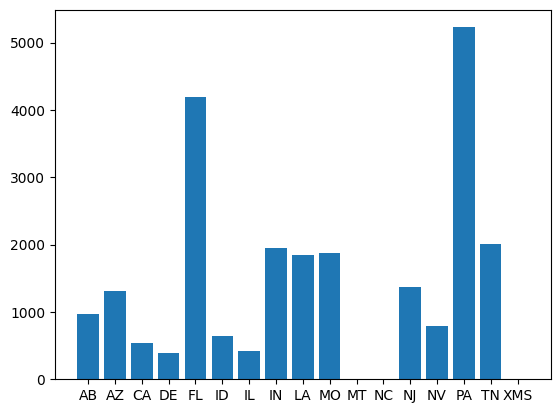

In [ ]:
#### 음식점 데이터 살펴보기
import matplotlib.pyplot as plt
stateWise = data2.groupby('state').count()
# stateWise
len(stateWise)

plt.bar(stateWise.index, stateWise['business_id'])

In [ ]:
data2['city'].value_counts()

PA     5228
FL     4199
TN     2015
IN     1952
MO     1880
LA     1853
NJ     1364
AZ     1308
AB      976
NV      793
ID      645
CA      541
IL      424
DE      390
NC        1
MT        1
XMS       1
Name: state, dtype: int64

In [ ]:
countryWise = data2.loc[data2['state'] == 'ON']
countryWise['city'] = countryWise['city']
countryWise = countryWise.groupby('city').count()

cities = countryWise.index.to_list()
cities = [c.lower() for c in cities]

countryWise['city'] = cities

countryWise

,business_id,name,address,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,isRestaurant,rank,city
city,,,,,,,,,,,,,,,,


In [ ]:
countryWise = data2.loc[data2['state'] == 'ON']
countryWise['city'] = countryWise['city']
countryWise = countryWise.groupby('city').count()

cities = countryWise.index.to_list()
cities = [c.lower() for c in cities]

countryWise['city'] = cities

countryWise

In [ ]:
import pandas as pd
# import h3

rw_data = pd.read_json(r'/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_academic_dataset_user.json'
, lines=True)

# # 레스토랑업체만 필터링 (category에서 hotel검색시 이상한 업체들도 나와서 이름으로 필터링)
# bs_data['name'] = bs_data['name'].str.lower()
# bs_data = bs_data[bs_data['name'].str.contains('hotel|motel| inn')]

# # H3 추가
# bs_data['h3'] = bs_data[['latitude', 'longitude']].apply(lambda x: h3.geo_to_h3(x['latitude'], x['longitude'], 7), axis=1)

# # 랭크 추가
# bs_data['rank'] = bs_data['stars'] * bs_data['review_count']

# # ...그외 생략

#  # CSV로 저장
# bs_data.to_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/business.csv', index=False)

In [ ]:
## 사용자 데이터
# import json
# import pandas as pd
# data_file = open('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_academic_dataset_user.json', encoding='UTF8')
# data = []
# for line in data_file:
#         data.append(json.loads(line))
# user_df = pd.DataFrame(data)
# data_file.close()

In [ ]:
# pkl로 저장
# user_df.to_pickle('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/user_data.pkl')

In [ ]:
user_df = pd.read_pickle('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/user_data.pkl')
user_df.head()

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


In [ ]:
### 리뷰데이터
# import json
# import pandas as pd
# data_file = open('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_academic_dataset_review.json', encoding='UTF8')
# data = []
# for line in data_file:
#         data.append(json.loads(line))
# review_df = pd.DataFrame(data)
# data_file.close()


In [ ]:
# review_df.to_pickle('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/review_data.pkl')

In [ ]:
review_df['isRestaurant'] = review_df.business_id.isin(restaurants_and_food_business_ids).astype(int)
review_df1 = review_df[review_df.loc[:,'isRestaurant'] == 1]

In [ ]:
# review_df1.to_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/review_restrant&food.csv', index=False)

In [ ]:
review_df1.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,isRestaurant
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,1
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,1
5,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31,1
11,l3Wk_mvAog6XANIuGQ9C7Q,ZbqSHbgCjzVAqaa7NKWn5A,EQ-TZ2eeD_E0BHuvoaeG5Q,4.0,0,0,0,"Locals recommended Milktooth, and it's an amaz...",2015-08-19 14:31:45,1
16,oyaMhzBSwfGgemSGuZCdwQ,Dd1jQj7S-BFGqRbApFzCFw,YtSqYv1Q_pOltsVPSx54SA,5.0,0,0,0,Tremendous service (Big shout out to Douglas) ...,2013-06-24 11:21:25,1


In [ ]:
# 음식점 리뷰 및 사용자만 이용
restaurants_and_food_business_ids = review_df1.user_id.to_list()
user_df['isRestaurant'] = user_df.user_id.isin(restaurants_and_food_business_ids).astype(int)
user_df1 = user_df[user_df.loc[:,'isRestaurant'] == 1]

In [ ]:
user_df1.shape

(892975, 23)

In [ ]:
user_df1.head()

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,isRestaurant
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,55,56,18,232,844,467,467,239,180,1
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,184,157,251,1847,7054,3131,3131,1521,1946,1
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,10,17,3,66,96,119,119,35,18,1
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,1,6,2,12,16,26,26,10,9,1
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,0,0,0,1,1,0,0,0,0,1


In [ ]:
# user_df1.to_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/user_restrant&food.csv', index=False)

### 데이터 정리

In [2]:
import pandas as pd

user_df = pd.read_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/user_restrant&food.csv', index_col=False)
review_df = pd.read_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/review_restrant&food.csv', index_col=False)
business_df = pd.read_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/business_food&restaurant.csv', index_col=False)

In [3]:
### 추천시스템 형식으로 데이터셋 만들기

user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892975 entries, 0 to 892974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             892975 non-null  object 
 1   name                892974 non-null  object 
 2   review_count        892975 non-null  int64  
 3   yelping_since       892975 non-null  object 
 4   useful              892975 non-null  int64  
 5   funny               892975 non-null  int64  
 6   cool                892975 non-null  int64  
 7   elite               69053 non-null   object 
 8   friends             892975 non-null  object 
 9   fans                892975 non-null  int64  
 10  average_stars       892975 non-null  float64
 11  compliment_hot      892975 non-null  int64  
 12  compliment_more     892975 non-null  int64  
 13  compliment_profile  892975 non-null  int64  
 14  compliment_cute     892975 non-null  int64  
 15  compliment_list     892975 non-nul

In [ ]:
user_df.head()

In [ ]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2154456 entries, 0 to 2154455
Data columns (total 10 columns):
 #   Column        Dtype  
---  ------        -----  
 0   review_id     object 
 1   user_id       object 
 2   business_id   object 
 3   stars         float64
 4   useful        int64  
 5   funny         int64  
 6   cool          int64  
 7   text          object 
 8   date          object 
 9   isRestaurant  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 164.4+ MB


In [ ]:
business_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23571 entries, 0 to 23570
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   business_id   23571 non-null  object 
 1   name          23571 non-null  object 
 2   address       23167 non-null  object 
 3   city          23571 non-null  object 
 4   state         23571 non-null  object 
 5   postal_code   23551 non-null  object 
 6   latitude      23571 non-null  float64
 7   longitude     23571 non-null  float64
 8   stars         23571 non-null  float64
 9   review_count  23571 non-null  int64  
 10  is_open       23571 non-null  int64  
 11  attributes    23343 non-null  object 
 12  categories    23571 non-null  object 
 13  hours         21235 non-null  object 
 14  isRestaurant  23571 non-null  int64  
 15  rank          23571 non-null  float64
dtypes: float64(4), int64(3), object(9)
memory usage: 2.9+ MB


In [ ]:
business_df.describe()

,latitude,longitude,stars,review_count,is_open,isRestaurant,rank
count,23571.000000,23571.000000,23571.000000,23571.000000,23571.000000,23571.0,23571.000000
mean,36.672232,-88.269737,3.465402,88.306181,0.724577,1.0,337.336939
std,6.007813,13.789325,0.930236,214.583943,0.446737,0.0,877.038345
min,27.564457,-120.083748,1.000000,5.000000,0.000000,1.0,5.000000
25%,30.012550,-90.243234,3.000000,13.000000,0.000000,1.0,38.000000
50%,38.735548,-86.111240,3.500000,30.000000,1.000000,1.0,99.000000
75%,39.953002,-75.433845,4.000000,82.000000,1.000000,1.0,304.000000
max,53.679197,-74.684399,5.000000,7568.000000,1.000000,1.0,30272.000000


In [ ]:
df1 = business_df.groupby('name').count()['business_id']
df1.head()

name
"Genuino" Italian Cafe'    1
$5 Fresh Burger Stop       1
'Merica Food Truck         1
'Ono Poke Co               1
'feine                     1
Name: business_id, dtype: int64

In [ ]:
df1 = business_df.groupby('name').count()['business_id']
df1 = pd.DataFrame(df1)
df1[df1.business_id == business_df.groupby('name').count()['business_id'].max()]

,business_id
name,
McDonald's,702


In [ ]:
df1[df1.business_id > 1].sort_values(by='business_id').tail(20)

,business_id
name,
Jersey Mike's Subs,92
Panera Bread,98
Jack in the Box,102
Panda Express,111
Sonic Drive-In,113
Arby's,115
Starbucks,148
Dunkin',155
Chipotle Mexican Grill,156


In [ ]:
# 비즈니스 테이블에서 추천시스템에 필요한 정보 :
business_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,isRestaurant,rank
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","restaurants, food, bubble tea, coffee & tea, b...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",1,320.0
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","burgers, fast food, sandwiches, food, ice crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '...",1,12.0
2,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ""'casual'"", 'Restaurants...","ice cream & frozen yogurt, fast food, burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '...",1,15.0
3,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ""'none'"", 'OutdoorSeating': 'None'...","vietnamese, food, restaurants, food trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'...",1,40.0
4,0bPLkL0QhhPO5kt1_EXmNQ,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,0,"{'OutdoorSeating': 'False', 'RestaurantsGoodFo...","food, delis, italian, bakeries, restaurants","{'Monday': '10:0-18:0', 'Tuesday': '10:0-20:0'...",1,450.0


In [ ]:
business_df.describe(include="object")

,business_id,name,address,city,state,postal_code,attributes,categories,hours
count,23571,23571,23167,23571,23571,23551,23343,23571,21235
unique,23571,15175,21233,736,17,1476,22749,18107,11037
top,MTSW4McQd7CbVtyjqoe9mw,McDonald's,222 E Market St,Philadelphia,PA,70130,"{'RestaurantsDelivery': 'True', 'RestaurantsTa...","restaurants, fast food, burgers","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."
freq,1,702,18,2532,5228,285,81,177,980


In [ ]:
r_data = business_df[['business_id', 'name', 'categories']]  # id, title, 장르 와 맞춰줌
r_data.head(2)

,business_id,name,categories
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,"restaurants, food, bubble tea, coffee & tea, b..."
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,"burgers, fast food, sandwiches, food, ice crea..."


In [ ]:
r_data = business_df[['business_id', 'name', 'categories']]  # id, title, 장르 와 맞춰줌
\
# 카테고리 원-핫 벡터(One-Hot Vector)로 변경
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
cat = cv.fit_transform(r_data.categories)
cv.vocabulary_

{'restaurants': 492,
 'food': 245,
 'bubble': 80,
 'tea': 584,
 'coffee': 139,
 'bakeries': 38,
 'burgers': 85,
 'fast': 231,
 'sandwiches': 506,
 'ice': 310,
 'cream': 163,
 'frozen': 248,
 'yogurt': 654,
 'vietnamese': 630,
 'trucks': 610,
 'delis': 183,
 'italian': 324,
 'cafes': 92,
 'bars': 45,
 'wine': 647,
 'nightlife': 400,
 'japanese': 326,
 'seafood': 511,
 'eatertainment': 212,
 'arts': 27,
 'entertainment': 218,
 'brewpubs': 76,
 'american': 15,
 'traditional': 602,
 'breweries': 74,
 'specialty': 549,
 'steakhouses': 559,
 'pizza': 446,
 'pasta': 426,
 'shops': 526,
 'event': 225,
 'planning': 447,
 'services': 515,
 'caterers': 111,
 'breakfast': 73,
 'brunch': 79,
 'diners': 192,
 'pets': 436,
 'pet': 435,
 'adoption': 6,
 'soup': 541,
 'cocktail': 138,
 'new': 397,
 'pubs': 470,
 'automotive': 36,
 'gas': 260,
 'stations': 558,
 'convenience': 153,
 'stores': 563,
 'salad': 503,
 'juice': 329,
 'smoothies': 536,
 'fruits': 249,
 'veggies': 624,
 'sporting': 553,
 'goods

In [ ]:
cat = pd.DataFrame(cat.toarray(),
                   columns = list(sorted(cv.vocabulary_.keys(), key = lambda x : cv.vocabulary_[x]))
)
cat.head(2)

,acai,accessories,accountants,active,activities,acupuncture,adoption,adult,advertising,advising,...,wine,wineries,wings,women,wraps,yelp,yoga,yogurt,your,yourself
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
r_data.shape, cat.shape

((23571, 3), (23571, 657))

In [ ]:
cat1 = pd.concat([r_data[['business_id']], cat], axis=1)
cat1 = cat1.set_index('business_id')
cat1.shape

(23571, 657)

In [ ]:
# 임의로 두개의 시강 유클리디언 거리 계산
a = cat1.iloc[1, :]
b = cat1.iloc[8, :]
import numpy as np
np.linalg.norm(a-b)

3.605551275463989

In [ ]:

cat = pd.DataFrame(cat.toarray(),
                   columns = list(sorted(cv.vocabulary_.keys(), key = lambda x : cv.vocabulary_[x]))
)

# Scikit-Learn의 NearestNeighbors를 이용하여
# 유사한 카테고리 음식정 100개 가져온 후 정렬
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=100).fit(cat1)
dis, inx = nbrs.kneighbors([a])
recommendations = r_data.loc[inx[0], ['name']]
recommendations['distance'] = dis[0]

dis, inx = nbrs.kneighbors([a])
recommendations = r_data.loc[inx[0], ['name']]
recommendations['distance'] = dis[0]
recommendations

recommendations.groupby('name').count()

NearestNeighbors(n_neighbors=100)

In [ ]:
dis, inx = nbrs.kneighbors([a])
recommendations = r_data.loc[inx[0], ['name']]
recommendations['distance'] = dis[0]
recommendations

recommendations.groupby('name').count()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,name,distance
21736,Culver's,0.0
21549,Culver's,0.0
1,Sonic Drive-In,0.0
15065,Culver's,0.0
12398,Culver's,0.0
...,...,...
15228,Sonic Drive-In,1.0
5576,Dairy Queen Grill & Chill,1.0
23158,Sonic Drive-In,1.0
5536,Culver's,1.0


In [ ]:
recommendations.groupby('name').count()

,distance
name,
California Burger,1
Culver's,15
Dairy Queen,27
Dairy Queen Grill & Chill,21
Freddy's Frozen Custard & Steakburgers,1
Hunger Burger,1
Sonic Drive-In,34


In [ ]:
# ratings.csv에서 평점 정보를 계산한 뒤에 추천 결과와 left join해서 붙이고
#, 정렬하면 유사한 장르의 영화를 평점순으로 추천
ratings_mean_count = review_df.groupby('business_id').agg({'stars':['mean','count']})
ratings_mean_count.columns = ['r_mean', 'r_count']

# r_mean 소수점 반올림
ratings_mean_count.r_mean = ratings_mean_count.r_mean.round(1)
ratings_mean_count

,r_mean,r_count
business_id,,
---kPU91CF4Lq2-WlRu9Lw,4.5,24
--0iUa4sNDFiZFrAdIWhZQ,3.2,14
--8IbOsAAxjKRoYsBFL-PA,2.9,27
--ZVrH2X2QXBFdCilbirsw,4.7,36
--epgcb7xHGuJ-4PUeSLAw,2.9,38
...,...,...
zzFCdBSW27eKFg-xG7cqAg,3.9,19
zzXRdzrVhfNWPHD2MeyWeA,2.1,15
zzbZtgPYZS8sTIWQH6DwEw,2.8,87


In [ ]:
# 기존 데이터 합쳐주기
recom = pd.merge(recommendations, ratings_mean_count, left_index = True, right_index=True, how='left')

# 거리순에 이어 평점, 평점수 순으로 정렬
recom.sort_values(['distance', 'r_mean', 'r_count'], ascending=[True,False,False], inplace=True)
recom  # rating이 없는 영화의 경우는 NaN으로 표시됨

,name,distance,r_mean,r_count
21736,Culver's,0.0,NaN,NaN
21549,Culver's,0.0,NaN,NaN
1,Sonic Drive-In,0.0,NaN,NaN
15065,Culver's,0.0,NaN,NaN
12398,Culver's,0.0,NaN,NaN
...,...,...,...,...
15228,Sonic Drive-In,1.0,NaN,NaN
5576,Dairy Queen Grill & Chill,1.0,NaN,NaN
23158,Sonic Drive-In,1.0,NaN,NaN
5536,Culver's,1.0,NaN,NaN


### User-Item Matrix

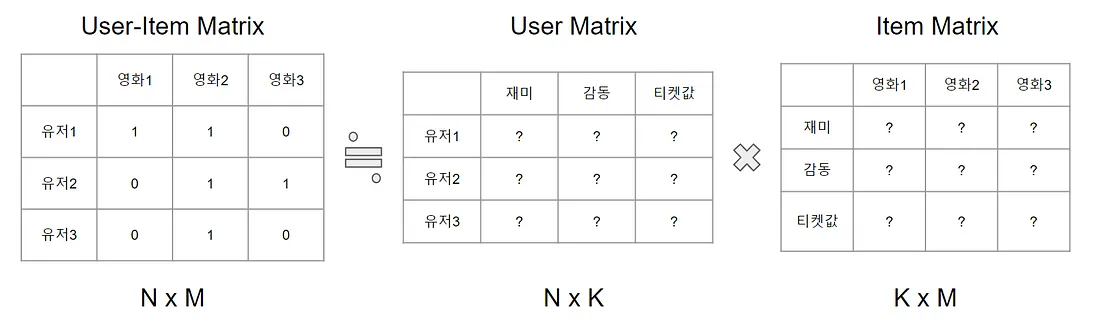

In [ ]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2154456 entries, 0 to 2154455
Data columns (total 10 columns):
 #   Column        Dtype  
---  ------        -----  
 0   review_id     object 
 1   user_id       object 
 2   business_id   object 
 3   stars         float64
 4   useful        int64  
 5   funny         int64  
 6   cool          int64  
 7   text          object 
 8   date          object 
 9   isRestaurant  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 164.4+ MB


In [ ]:
review_df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,isRestaurant
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,1
1,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,1
2,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31,1
3,l3Wk_mvAog6XANIuGQ9C7Q,ZbqSHbgCjzVAqaa7NKWn5A,EQ-TZ2eeD_E0BHuvoaeG5Q,4.0,0,0,0,"Locals recommended Milktooth, and it's an amaz...",2015-08-19 14:31:45,1
4,oyaMhzBSwfGgemSGuZCdwQ,Dd1jQj7S-BFGqRbApFzCFw,YtSqYv1Q_pOltsVPSx54SA,5.0,0,0,0,Tremendous service (Big shout out to Douglas) ...,2013-06-24 11:21:25,1


In [ ]:
# 음식점 개수 많은 city top15
df2 = business_df.groupby('city').count()['business_id']
df2.head(1)

city
Abington    16
Name: business_id, dtype: int64

In [ ]:
# 리뷰 많은 음식점 top 15


In [1]:
import pandas as pd


#### 1. 상위 N 개 추천 1. 리뷰 많은 순

#### 1. 상위 N 개 추천 2. 평점 높은 순

#### 내위치 선택 - 위도, 경도 입력

```
# 코드로 형식 지정됨
```



In [ ]:
### 위치기반

#### 협업필터링


In [1]:
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.metrics.pairwise import cosine_similarity
import operator
%matplotlib inline

In [27]:
# user_df = pd.read_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/user_restrant&food.csv', index_col=False)
# review_df = pd.read_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/review_restrant&food.csv', index_col=False)
business_df = pd.read_csv('/content/drive/MyDrive/대학원/202309자료/추천시스템/data/business_food&restaurant.csv', index_col=False)

In [12]:
business_df.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'isRestaurant', 'rank'],
      dtype='object')

In [29]:
# data1 = pd.read_json(r'/content/drive/MyDrive/대학원/202309자료/추천시스템/data/yelp_academic_dataset_business.json'
# , lines=True)
# data1['categories'] = data1['categories'].str.lower()
mask_restaurants = business_df['city'].str.contains('Philadelphia')
# mask_food = data1['categories'].str.contains('food')
df = business_df[mask_restaurants]
df.head(2)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,isRestaurant,rank
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","restaurants, food, bubble tea, coffee & tea, b...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",1,320.0
7,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,1,"{'OutdoorSeating': 'True', 'RestaurantsPriceRa...","eatertainment, arts & entertainment, brewpubs,...","{'Monday': '0:0-0:0', 'Wednesday': '16:0-22:0'...",1,227.5


In [30]:
p_li = df.business_id.to_list()
user_rw['isPhiladelphia'] = user_rw.business_id.isin(p_li).astype(int)
user_rw = user_rw[user_rw.loc[:,'isPhiladelphia'] == 1]
# data2 = data2.iloc[:,:36]
# 랭크 추가
# data2['rank'] = data2['stars'] * data2['review_count']
# data2.shape

<ipython-input-30-64aaedfc7bed>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_rw['isPhiladelphia'] = user_rw.business_id.isin(p_li).astype(int)


In [3]:
user_as = user_df.contains()[['user_id', 'average_stars']]  #user 별로 평균평점

In [4]:
user_rw = review_df[['user_id', 'business_id', 'stars']]  # 사용자 음식점별 평점

In [31]:
ratings_mean_count = user_rw.groupby(['user_id', 'business_id']).agg({'stars':['mean','count']})
ratings_mean_count.columns = ['user_m', 'user_c']

In [32]:
user_rw.shape

(288666, 4)

In [33]:
df

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,isRestaurant,rank
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","restaurants, food, bubble tea, coffee & tea, b...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",1,320.0
7,aPNXGTDkf-4bjhyMBQxqpQ,Craft Hall,901 N Delaware Ave,Philadelphia,PA,19123,39.962582,-75.135657,3.5,65,1,"{'OutdoorSeating': 'True', 'RestaurantsPriceRa...","eatertainment, arts & entertainment, brewpubs,...","{'Monday': '0:0-0:0', 'Wednesday': '16:0-22:0'...",1,227.5
13,ppFCk9aQkM338Rgwpl2F5A,Wawa,3604 Chestnut St,Philadelphia,PA,19104,39.954573,-75.194894,3.0,56,1,"{'Alcohol': ""u'none'"", 'RestaurantsGoodForGrou...","restaurants, automotive, delis, gas stations, ...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",1,168.0
25,WYYdQDjx-DsCanlP0DpImQ,J Sushi,243 S 10th St,Philadelphia,PA,19107,39.947033,-75.157434,4.5,72,0,"{'Ambience': ""{'touristy': False, 'hipster': F...","seafood, restaurants, sushi bars, japanese","{'Tuesday': '11:0-22:0', 'Wednesday': '11:0-22...",1,324.0
32,O1oZpbZNDMH_gz8DhsZCdA,Wendy's,700 E. Hunting Park,Philadelphia,PA,19124,40.012141,-75.115015,1.5,15,1,"{'RestaurantsTakeOut': 'True', 'RestaurantsPri...","burgers, restaurants, fast food","{'Monday': '10:0-2:0', 'Tuesday': '10:0-2:0', ...",1,22.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23548,K1SsvIPfFcHniNSPc3IG7g,Flip-N-Pizza,1308 W Girard Ave,Philadelphia,PA,19123,39.970720,-75.157752,4.0,16,1,"{'WiFi': ""u'no'"", 'BYOB': 'False', 'Restaurant...","restaurants, american (traditional), chicken w...","{'Monday': '0:0-0:0', 'Tuesday': '15:0-1:30', ...",1,64.0
23554,OfRbGvHn-nAnQMqNxiIpcA,Grilly Cheese,3306 Arch St,Philadelphia,PA,19104,39.957447,-75.189916,3.0,5,1,"{'BikeParking': 'True', 'WheelchairAccessible'...","specialty food, event planning & services, res...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'...",1,15.0
23561,VZbkSeZtFynEascotq7ExA,Ali Baba Magic Food,37TH And Walnut,Philadelphia,PA,19104,39.953391,-75.196765,4.0,8,0,"{'GoodForKids': 'False', 'RestaurantsReservati...","restaurants, food stands",NaN,1,32.0
23564,wVxXRFf10zTTAs11nr4xeA,PrimoHoagies,6024 Ridge Ave,Philadelphia,PA,19128,40.032483,-75.214430,3.0,55,1,"{'NoiseLevel': ""u'average'"", 'RestaurantsTakeO...","restaurants, specialty food, food, sandwiches,...","{'Monday': '10:0-21:0', 'Tuesday': '10:0-21:0'...",1,165.0


In [9]:
# 사용자 - 음식점 - 평점
print(ratings_mean_count.shape)
ratings_mean_count.head()  # 동일한 음식점 평점 평균

(2081546, 2)


user_m  user_c
user_id                business_id                           
---2PmXbF47D870stH1jqA 0ZsqqzHu1HHkDdIKoivi5g     5.0       1
                       1An4DxtMmvvSe0HX4viRCA     5.0       3
                       KP5OncF2jhT7_J1phHPPww     5.0       1
                       L5LLN0RafiV1Z9cddzvuCw     5.0       1
                       MxRZHZoDVVnN7EvMAHf1EA     5.0       1

In [11]:
ratings_mean_count = ratings_mean_count.reset_index()

In [34]:
ratings_mean_count_b = df.groupby('business_id').agg({'stars':['mean','count']})
ratings_mean_count_b.columns = ['r_mean', 'r_count']

# r_mean 소수점 반올림
ratings_mean_count_b.r_mean = ratings_mean_count_b.r_mean.round(1)
ratings_mean_count_b = ratings_mean_count_b.reset_index()

In [35]:
ratings_mean_count, ratings_mean_count_b

(                                               user_m  user_c
 user_id                business_id                           
 --0kuuLmuYBe3Rmu0Iycww qcguEeAMP0XwFLYqhwX2hg     5.0       1
 --13zE3NaRvLSrmfTVnFJA U2y7fsqDgxAXskoJNVxbwg     2.0       1
 --2tyArRmSoyKx5r-FVG0A jHZS9GIhW7s9r4w5w-0A0Q     3.0       1
 --2vR0DIsmQ6WfcSzKWigw krCwF4raTYvBcCEwcbA88Q     4.0       1
 --4AjktZiHowEIBCMd4CZA Yz0fJyBkUF8VZBvwFswkRQ     5.0       1
 ...                                               ...     ...
 zziJLt25YU6dp01sewR-IQ K3RURR9lIEE4JjOaPt99zg     5.0       1
                        krCwF4raTYvBcCEwcbA88Q     3.0       1
 zzkAl8r4-N5KmYI0GysWmQ cGX-1IUwXOjkUqZbkKYcjw     5.0       1
 zzrhWsiCwAKQzbgMZIOtgg vpLMV6pHa1oI71jYaCVFzA     5.0       1
                        zvixukO8M4PCmMMaZOldPg     5.0       1
 
 [279466 rows x 2 columns],
                  business_id  r_mean  r_count
 0     -0TffRSXXIlBYVbb5AwfTg     4.5        1
 1     -40qQXB8JsneSiDqXMjoeg     4.0        1
 2     -6n

In [36]:
# 아이템 평균 score
item = ratings_mean_count_b.reset_index()[['business_id','r_mean']]
item.head(2)

,business_id,r_mean
0,-0TffRSXXIlBYVbb5AwfTg,4.5
1,-40qQXB8JsneSiDqXMjoeg,4.0


In [104]:
# ratings_mean_count.to_pickle('/content/drive/MyDrive/대학원/202309자료/추천시스템/user_rmc.pkl')
# item.to_pickle('/content/drive/MyDrive/대학원/202309자료/추천시스템/item.pkl')

In [37]:
# Join the two dataframes on the scls_c_nm columns
merged = user_rw.merge(item, left_on = 'business_id', right_on = 'business_id', suffixes= ['_user', ''])
merged.rename(columns = {'stars':'user_rating'}, inplace = True)

In [18]:
merged.head()

,user_id,business_id,user_rating,r_mean
0,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,3.0
1,Iaee7y6zdSB3B-kRCo4z1w,XQfwVwDr-v0ZS3_CbbE5Xw,2.0,3.0
2,ejFxLGqQcWNLdNByJlIhnQ,XQfwVwDr-v0ZS3_CbbE5Xw,4.0,3.0
3,f7xa0p_1V9lx53iIGN5Sug,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,3.0
4,dCooFVCk8M1nVaQqcfTL3Q,XQfwVwDr-v0ZS3_CbbE5Xw,2.0,3.0


In [97]:
# merged.to_pickle('/content/drive/MyDrive/대학원/202309자료/추천시스템/ratings.pkl')

In [ ]:
## 데이터 너무 커서 사용자 줄임(음식점 Philadelphia 로 한정)

In [38]:
# User CF - row : 사용자 , column : 아이템, values : 평가점수
# Item CF - row : 아이템 , column : 사용자, values : 평가점수
piv = merged.pivot_table(index=['user_id'], columns=['business_id'], values='user_rating')

In [41]:
print(piv.shape)
piv.tail()

(120184, 2534)


business_id,-0TffRSXXIlBYVbb5AwfTg,-40qQXB8JsneSiDqXMjoeg,-6nQZ-QCkAyNHdtaxOxDpQ,-AanHawaDlzWHQjrqRRWig,-Ah-gbZpa-IiQVIrhKRhhA,-BLVl824WRLFIm_uiHmkbA,-Bhoyo7LL97tgt9Hze0Saw,-FMI0_EhMjwXaAgHVGuG2Q,-KncfNxXHo2DA46fR39K5w,-LmhsdQproqCf5EQoD06rQ,...,zrQAj03aHI7kpmAiyKcKhA,zropQGh2fc7PMpzd32vneQ,zucC7rHpXPYBu7aEqj0NUw,zujdPV3HT-Y-CKE1GgkMHQ,zvixukO8M4PCmMMaZOldPg,zwd4dyQ5ovnjVojWfAuhMw,zxY4DgtXsVHihSUpsmwamg,zy7uNOvpykrq-XlmDY_wHA,zyMkbavgHASQtqVwaock9A,zz-fcqurtm77bZ_rVvo2Lw
user_id,,,,,,,,,,,,,,,,,,,,,
zzeYPGdmowtbqjZIbKZpqw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zzfdOXALn161r4ZlMWc_vw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zziJLt25YU6dp01sewR-IQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zzkAl8r4-N5KmYI0GysWmQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zzrhWsiCwAKQzbgMZIOtgg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN


In [42]:
# 사용자 개개인의 평가 척도를 조정해주기 위해 표준화 작업을 진행
# Normalize the values
piv_norm = piv.apply(lambda x: (x-np.mean(x))/(np.max(x)-np.min(x)), axis=1) # min-max scaling

# Null 값을 0으로 대체
# Drop all columns containing only zeros representing users who did not rate
piv_norm.fillna(0, inplace=True)
piv_norm = piv_norm.T
piv_norm = piv_norm.loc[:, (piv_norm != 0).any(axis=0)]


# 유사도 계산, scipy의 csr_matrix
# Our data needs to be in a sparse matrix format to be read by the following functions
piv_sparse = sp.sparse.csr_matrix(piv_norm.values)

In [43]:
piv_sparse = sp.sparse.csr_matrix(piv_norm.values)
item_similarity = cosine_similarity(piv_sparse)
user_similarity = cosine_similarity(piv_sparse.T)  # 전치

In [44]:
# Inserting the similarity matricies into dataframe objects
item_sim_df = pd.DataFrame(item_similarity, index = piv_norm.index, columns = piv_norm.index)
user_sim_df = pd.DataFrame(user_similarity, index = piv_norm.columns, columns = piv_norm.columns)

In [45]:
# This function will return the top 10 shows with the highest cosine similarity value
def top_item(item_nm):
    count = 1
    print('Similar shows to {} include:\n'.format(item_nm))
    result = item_sim_df.loc[~item_sim_df.index.isin([item_nm]), item_nm].sort_values(ascending = False)[:10]
    for item, score in result.items():
        print('No. {}: {}({:.2f})'.format(count, item , score))
        count +=1

In [46]:
# This function will return the top 5 users with the highest similarity value
def top_users(user):
    if user not in piv_norm.columns:
        return('No data available on user {}'.format(user))

    print('Most Similar Users:\n')
    result = user_sim_df.sort_values(by=user, ascending=False).loc[:,user][1:11]
    for user, sim in result.items():
        print('User #{0}, Similarity value: {1:.2f}'.format(user, sim))

In [65]:
print(list(merged['business_id'].sample(1)))

['BtxUZn4d7yxsHwdlRq1dkw']


In [66]:
# 음식점 램덤
print(merged['business_id'].sample(1))
top_item(list(merged['business_id'].sample(1))[0])

140661    SwdHTo4A_5eA8QsfelTPdg
Name: business_id, dtype: object
Similar shows to bgxDswHIdFP0Go0pNfyAAw include:

No. 1: 0RSws84Im4CsZ-W9biXv2g(0.05)
No. 2: VBONwHcqkxYTHfxmdKGhkw(0.05)
No. 3: WbxPdq_PgVvCI462l0vPEQ(0.04)
No. 4: CnL9asvqi5hwXc1sj7bqig(0.03)
No. 5: Q81Xj-eCVxi8mttVMn2UiQ(0.03)
No. 6: 1FeB0RbAz9kdoZsTf05arw(0.03)
No. 7: WCpFpsvJawCOYAPPTp83jA(0.03)
No. 8: bzOCjuydWTkgkbZeaec8Zg(0.03)
No. 9: N2g0Com0YXFgRLIR4KLEuQ(0.03)
No. 10: mzFIAmpX1Ef83Djqs19vZQ(0.03)


In [67]:
print(merged['user_id'].sample(1))
top_users(list(merged['user_id'].sample(1))[0])

250995    Qp4MYYSB5_R2r2JsE0HvKA
Name: user_id, dtype: object
Most Similar Users:

User #9fP3KiiVpFVYcnqgD3aZJw, Similarity value: 0.61
User #yi0j1LB759eX9V8j5LLuPw, Similarity value: 0.57
User #IVqXMGaA-kI_-jIzA6tIrg, Similarity value: 0.54
User #WjDSSPFOu9JrR0XmidZRpQ, Similarity value: 0.53
User #bq1r3VN1PpII_A7ndvY8qg, Similarity value: 0.51
User #hrUCdIO0LPY3QH_4LApD6g, Similarity value: 0.51
User #ekdwfMj3KZQJ72pXx1mS-Q, Similarity value: 0.51
User #9eko0rEC4G3Wc15VdOZ_Jg, Similarity value: 0.51
User #_J2VfQfT0FfNuZA3Yb1_jQ, Similarity value: 0.51
User #Ss6Fz9oK7HCOvYllxpdwEw, Similarity value: 0.49


In [ ]:
top_users(214)

In [77]:
r_data = df[['business_id', 'name', 'categories']]  # id, title, 장르 와 맞춰줌, 필라델피아

# 카테고리 원-핫 벡터(One-Hot Vector)로 변경
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
cat = cv.fit_transform(r_data.categories)
cat = pd.DataFrame(cat.toarray(),
                   columns = list(sorted(cv.vocabulary_.keys(), key = lambda x : cv.vocabulary_[x]))
)
cat.head(2)

,acai,active,adoption,adult,advising,afghan,african,airport,american,arabic,...,waffles,wedding,whiskey,wholesale,wine,wineries,wings,wraps,yogurt,yourself
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [78]:
cat.shape

(2534, 384)

In [81]:
# SwdHTo4A_5eA8QsfelTPdg 인덱스
r_data =r_data.reset_index()
r_data[r_data.business_id == 'SwdHTo4A_5eA8QsfelTPdg']

,index,business_id,name,categories
1070,9919,SwdHTo4A_5eA8QsfelTPdg,Food for All Market,"health markets, specialty food, restaurants, b..."


In [95]:
# 140661    SwdHTo4A_5eA8QsfelTPdg
# Name: business_id, dtype: object
# Similar shows to bgxDswHIdFP0Go0pNfyAAw include:

# No. 1: 0RSws84Im4CsZ-W9biXv2g(0.05)
# No. 2: VBONwHcqkxYTHfxmdKGhkw(0.05)
# No. 3: WbxPdq_PgVvCI462l0vPEQ(0.04)
# No. 4: CnL9asvqi5hwXc1sj7bqig(0.03)
# No. 5: Q81Xj-eCVxi8mttVMn2UiQ(0.03)

print('입력된 음식점 : ', list(r_data[r_data.business_id == 'SwdHTo4A_5eA8QsfelTPdg']['name']))
print(list(r_data[r_data.business_id == '0RSws84Im4CsZ-W9biXv2g']['name']))
print(list(r_data[r_data.business_id == 'VBONwHcqkxYTHfxmdKGhkw']['name']))
print(list(r_data[r_data.business_id == 'WbxPdq_PgVvCI462l0vPEQ']['name']))
print(list(r_data[r_data.business_id == 'CnL9asvqi5hwXc1sj7bqig']['name']))
print(list(r_data[r_data.business_id == 'Q81Xj-eCVxi8mttVMn2UiQ']['name']))

입력된 음식점 :  ['Food for All Market']
['Rio Brazilan Steak Truck']
["Keating's Rope & Anchor"]
["Dunkin'"]
['Varalli']
["Jimmy John's"]


In [83]:
# Scikit-Learn의 NearestNeighbors를 이용하여
# 유사한 카테고리 음식정 100개 가져온 후 정렬
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=100).fit(cat)

# 임의로 SwdHTo4A_5eA8QsfelTPdg 유클리디언 거리 계산
a = cat.iloc[1070, :]
# b = cat1.iloc[8, :]

# import numpy as np
# np.linalg.norm(a-b)


dis, inx = nbrs.kneighbors([a])
recommendations = r_data.loc[inx[0], ['name']]
recommendations['distance'] = dis[0]
recommendations

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,name,distance
1070,Food for All Market,0.000000
99,The Pink Dolphin,2.236068
1121,Mariposa Food Co-op,2.449490
188,Essene Market & Café,2.449490
1181,Dessertcrazy,2.449490
...,...,...
1701,Auntie Anne's,3.000000
273,Tartes Pastry Shop,3.000000
674,Pagano's Steaks,3.000000
2272,Subway,3.000000


In [91]:
recommendations.groupby('name').count().sort_values(by='distance', ascending =False).rename({'distance':'cnt'}, axis=1)

,cnt
name,
Subway,7
PrimoHoagies,2
Amoroso's,1
Pagoda Noodle Cafe,1
Salam Cafe and Market,1
...,...
Hesh's Eclair Bake Shoppe,1
Haegeles Bakery,1
Grilladelphia,1


In [96]:
# 지정 사용자의 유사도가 높은 10명의 비슷한 사용자를 기준으로 item을 추천해주는 함수
# This function constructs a list of lists containing the highest rated shows per similar user
# and returns the name of the show along with the frequency it appears in the list

def similar_user_recs(user):
    if user not in piv_norm.columns:
        return('No data available on user {}'.format(user))

    # 유사도가 높은 10명의 사용자를 가져옵니다.
    sim_users = user_sim_df.sort_values(by=user, ascending=False).index[1:11]
    best = []
    most_common = {}


    for i in sim_users:
        # 유사도가 높은 10명의 사용자들이 평가점수를 높게 주었던 item list를 가져옵니다.
        # 단, 주의해야할 점은 추천하려고 하는 대상 user가 평가하지 않았던 아이템이어야 합니다.
        result_sorted = piv_norm.loc[:, i][(piv_norm.loc[:,user] == 0)].sort_values(ascending = False)
        best.append(result_sorted.index[:5].tolist())
#     print(best)
    for i in range(len(best)):
        for j in best[i]:
            if j in most_common:
                most_common[j] += 1
            else:
                most_common[j] = 1
    sorted_list = sorted(most_common.items(), key=operator.itemgetter(1), reverse=True)
    return sorted_list[:5]

In [ ]:
# item_rfm.head(2)
import pandas as pd
item_rfm = pd.read_pickle('./data/item_rfm.pkl')
ratings = item_rfm[['cno','scls_c_nm','RFM_Score']]
itemRatings = ratings.pivot_table(index=['cno'],columns=['scls_c_nm'],values='RFM_Score')
item_score = pd.read_pickle('./data/item_score.pkl')
items = item_score[['scls_c_nm','RFM_Score']]
item_ratings = pd.merge(items, ratings, left_on='scls_c_nm', right_on='scls_c_nm')

In [1]:
import pandas as pd
item_ratings = pd.read_pickle('/content/drive/MyDrive/대학원/202309자료/추천시스템/ratings.pkl')
ratings = pd.read_pickle('/content/drive/MyDrive/대학원/202309자료/추천시스템/user_rmc.pkl')
itemRatings = ratings.pivot_table(index=['user_id'],columns=['business_id'],values='user_m')
# items = pd.read_pickle('/content/drive/MyDrive/대학원/202309자료/추천시스템/item.pkl')
# item_ratings = pd.merge(items, ratings, left_on='scls_c_nm', right_on='scls_c_nm')
ratings = ratings.reset_index()

In [2]:
ratings = ratings.reset_index()

In [107]:
item_ratings.head(1)

,user_id,business_id,user_rating,isPhiladelphia,r_mean
0,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,4.0


In [5]:
from surprise import Dataset
from surprise import Reader
from collections import defaultdict

reader = Reader(rating_scale=(ratings['user_m'].min(), ratings['user_m'].max()))
data = Dataset.load_from_df(ratings[['user_id', 'business_id', 'user_m']],reader)

from surprise import SVD
from surprise import NormalPredictor
from surprise.model_selection import GridSearchCV

# 하이퍼 파라미터 그리드 검색을 해서 최적의 파라미터를 찾는다
# scikit-learn의 GridSearchCV와 아주 흡사
# - n_factors: 축소 차원수 (앞 그림에서 시그마 행렬의 차원수 - r)
# - n_epochs: 전체 데이터 셋을 훈련시키는 횟수
# - lr_all: 학습률

# param_grid = {
#   'n_epochs': [20, 30],
#   'lr_all': [0.005, 0.010],
#   'n_factors': [50, 100]
# }

# 3-폴드 교차검증을 하고 두 개의 비용함수를 사용: RMSE와 MAE (Mean Absolute Error)
# gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
# gs.fit(data)

# RMSE
# print("Best RMSE score attained: ", gs.best_score['rmse'])
# print("Best RMSE params: ", gs.best_params['rmse'])

# # MAE
# print("Best RAE score attained: ", gs.best_score['mae'])
# print("Best RAE params: ", gs.best_params['mae'])


In [4]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 772.0/772.0 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.3-cp310-cp310-linux_x86_64.whl size=3163762 sha256=af8b0a3f401063fe964fe2b0eda1f6ec489767364461050d365ad8d7f8eec07b
  Stored in directory: /root/.cache/pip/wheels/a5/ca/a8/4e28def53797fdc4363ca4af740db15a9c2f1595ebc51fb445
Successfully built scikit-surprise


In [6]:
# svd = gs.best_estimator['rmse']
# trainset = data.build_full_trainset()
# svd.fit(trainset)

# uid = str(5602)  # raw user id (as in the ratings file). They are **strings**!
# iid = str('선글라스(특정)')  # raw item nm (as in the ratings file). They are **strings**!

# get a prediction for specific users and items.
# pred = svd.predict(uid, iid, verbose=True)   # r_ui=4,


# Train/Test Split로 훈련하고 성능 평가해보기

from surprise import accuracy
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=.25)

svd = SVD()
svd.fit(trainset)
predictions = svd.test(testset)

# # Then compute RMSE
# accuracy.rmse(predictions)
# testset[0:10]

In [7]:
# top-N 정확도 계산
# 사용자별로 10개의 추천 아이템을 생성
# 인자인 predictions로는 SVD의 test의 리턴값을 사용
def get_top_n(predictions, n=10):

    top_n = defaultdict(list)

    # predictions의 각 레코드는 (사용자 ID, 아이템 ID, 실제 평점, 예측 평점)으로 구성
    for uid, iid, true_r, est, _ in predictions:
        # 사용자별로 영화ID와 예측 평점을 같이 저장
        top_n[uid].append((iid, est))

    # 위에서 채워진 top_n을 사용자ID를 가지고 예측평점이 높은 n개의 영화로 교체
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [ ]:
from surprise.model_selection import LeaveOneOut

# 각 사용자별로 하나의 평점만을 테스트셋에 보관 (n_splits가 1 즉 1개의 폴드)
LOOCV = LeaveOneOut(n_splits=1, random_state=1)
ratingCutoff = 4.0

for trainSet, testSet in LOOCV.split(data):
  pass

len(testSet)

# 훈련 데이터셋으로 학습
svd.fit(trainSet)


# 훈련 데이터셋에 있지 않은 모든 데이터를 테스트셋으로 리턴
bigTestSet = trainSet.build_anti_testset()

print(len(bigTestSet))

# 위에서 리턴된 데이터에 대해 평점 예측
allPredictions = svd.test(bigTestSet)

# 각 사용자별로 아직 평점이 없는 음식저들을 대상으로 top 20 평점 리스트를 추출
topNPredicted = get_top_n(allPredictions, n=20)

# 예를 들어 사용자 '1'의 추천 리스트를 확인
for tnp in topNPredicted['1']:
  # tnp는 tuple로 음식점ID와 평점으로 구성
  print(tnp)


# top N 정확도를 계산
hits = 0
total = 0

# 남겨졌던 데이터의 사용자들을 대상으로 cutoffRating이상의 평점을 갖는 아이템이 추천되었는지 확인
for userID, business_ID, trueRating in testSet:
    # 높은 평점이 매칭되는 경우만 고려
    if (trueRating >= ratingCutoff):
        # 사용자의 추천 리스트를 확인
        for b_ID, predictedRating in topNPredicted[userID]:
            # 해당 사용자의 추천 아이템에 해당 음식점이 존재하는 경우에만 카운트
            if (business_ID == b_ID):
                hits += 1
                break
        total += 1

print(hits/float(total)*100.)

99473202
